In [1]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import newton
import matplotlib.pyplot as plt
from dataclasses import dataclass
from utils import *

In [2]:
def simulate_sabr(n_steps, n_paths, T, params, switch_time=None, bins=None):
    alpha, rho, nu, s0 = params['alpha'], params['rho'], params['nu'], params['s0']
    dt, sqrtdt = T / n_steps, np.sqrt(T / n_steps)
    rho_c = np.sqrt(1 - rho**2)
    drift = nu * sqrtdt, 0.5 * nu**2 * dt   # (scale, ito correction)

    def _phase(n, vol0):
        W, V = np.random.normal(size=(2, n, n_paths))
        log_v = np.zeros((n + 1, n_paths))
        np.cumsum(drift[0] * W - drift[1], axis=0, out=log_v[1:])
        vol = vol0 * np.exp(log_v)
        inc = np.zeros((n + 1, n_paths))
        np.cumsum(vol[:-1] * (rho * W + rho_c * V) * sqrtdt, axis=0, out=inc[1:])
        return vol, inc

    if switch_time and bins is not None:
        k = int(round(switch_time / dt))
        vol1, inc1 = _phase(k, alpha)
        bins = np.sort(bins)
        idx  = np.clip(np.searchsorted(bins, vol1[-1]), 1, len(bins) - 1)
        snap = np.where(np.abs(vol1[-1] - bins[idx-1]) <= np.abs(vol1[-1] - bins[idx]), bins[idx-1], bins[idx])
        vol2, inc2 = _phase(n_steps - k, snap)
        vol   = np.vstack([vol1,        vol2[1:]])
        stock = np.vstack([inc1 + s0, (inc2 + inc1[-1] + s0)[1:]])
    else:
        vol, inc = _phase(n_steps, alpha)
        stock = inc + s0

    return stock, vol

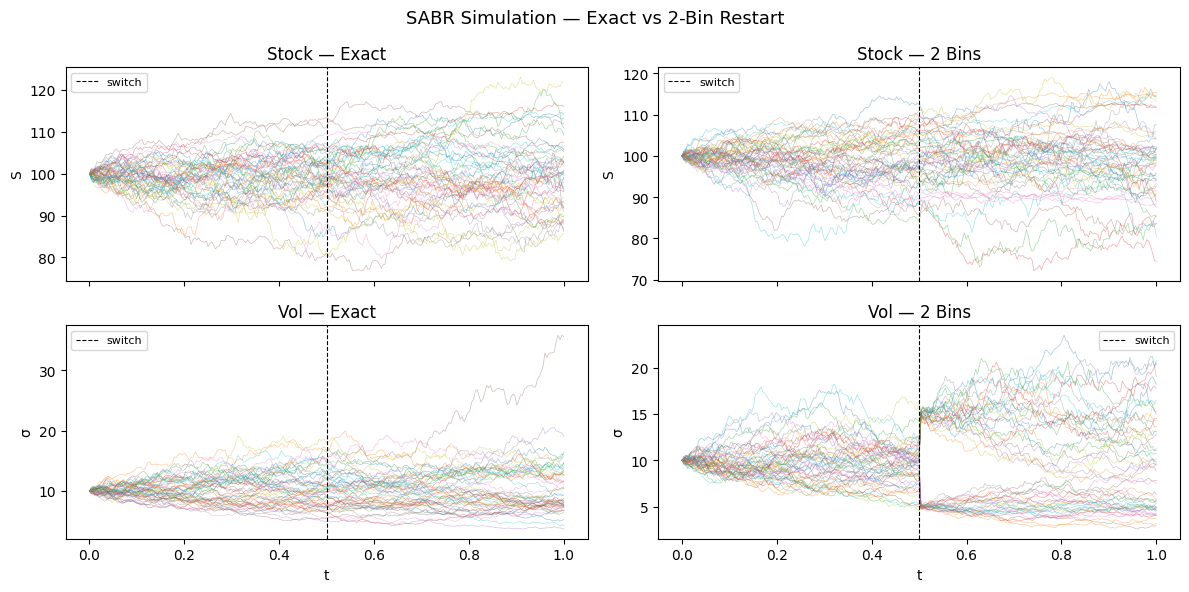

In [3]:
p      = {'alpha':10, 'rho':-0.5, 'nu':0.4, 's0':100}
T, n_steps, n_paths = 1.0, 252, 1000
switch_time = 0.5
bins = np.array([5, 15])

S_exact, V_exact = simulate_sabr(n_steps, n_paths, T, p)
S_bins,  V_bins  = simulate_sabr(n_steps, n_paths, T, p, switch_time, bins)

t = np.linspace(0, T, n_steps + 1)

fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
fig.suptitle("SABR Simulation — Exact vs 2-Bin Restart", fontsize=13)

for ax, paths, title in zip(axes[0], [S_exact, S_bins], ["Stock — Exact", "Stock — 2 Bins"]):
    ax.plot(t, paths[:, :50], lw=0.5, alpha=0.4)
    ax.axvline(switch_time, color="k", lw=0.8, ls="--", label="switch")
    ax.set_title(title); ax.set_ylabel("S"); ax.legend(fontsize=8)

for ax, paths, title in zip(axes[1], [V_exact, V_bins], ["Vol — Exact", "Vol — 2 Bins"]):
    ax.plot(t, paths[:, :50], lw=0.5, alpha=0.4)
    ax.axvline(switch_time, color="k", lw=0.8, ls="--", label="switch")
    ax.set_title(title); ax.set_ylabel("σ"); ax.set_xlabel("t"); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [4]:
# parameters
p           = {'alpha':10, 'rho':-0.1, 'nu':0.4, 's0':100}
T           = 1.0;  n_steps = 252;  n_paths = 500_000;  switch_time = 0.5
bins_1_2      = np.array([10])
# bins_1_1      = np.array([15])
# bins_1_3      = np.array([5])
bins_2      = np.array([12, 8])
bins_3      = np.array([10, 5, 15])
maturities  = np.linspace(0.5, 1.0, 6)
moneyness   = np.linspace(0.85, 1.15, 15)
dt          = T / n_steps

# simulate
S_exact, _ = simulate_sabr(n_steps, n_paths, T, p)
S_b1,    _ = simulate_sabr(n_steps, n_paths, T, p, switch_time, bins_1_2)
# S_b1_1,    _ = simulate_sabr(n_steps, n_paths, T, p, switch_time, bins_1_1)
# S_b1_3,    _ = simulate_sabr(n_steps, n_paths, T, p, switch_time, bins_1_3)
S_b2,    _ = simulate_sabr(n_steps, n_paths, T, p, switch_time, bins_2)
S_b3,    _ = simulate_sabr(n_steps, n_paths, T, p, switch_time, bins_3)

In [5]:
cases  = [("No bins", S_exact), ("1 bin", S_b1), ("2 bins", S_b2), ("3 bins", S_b3)]
colors = {"No bins": "steelblue","1 bin": "tomato", "2 bins": "pink", "3 bins": "seagreen"}

# Compute smiles
def smiles_for(S):
    out = []
    for tau in maturities:
        idx     = int(round(tau / dt))
        St      = S[idx]
        F       = np.mean(St)
        strikes = moneyness * F
        vols    = mc_iv(F, tau, strikes, St)
        out.append({"strikes": strikes, "vols": vols, "F": F})
    return out

smiles = {label: smiles_for(S) for label, S in cases}

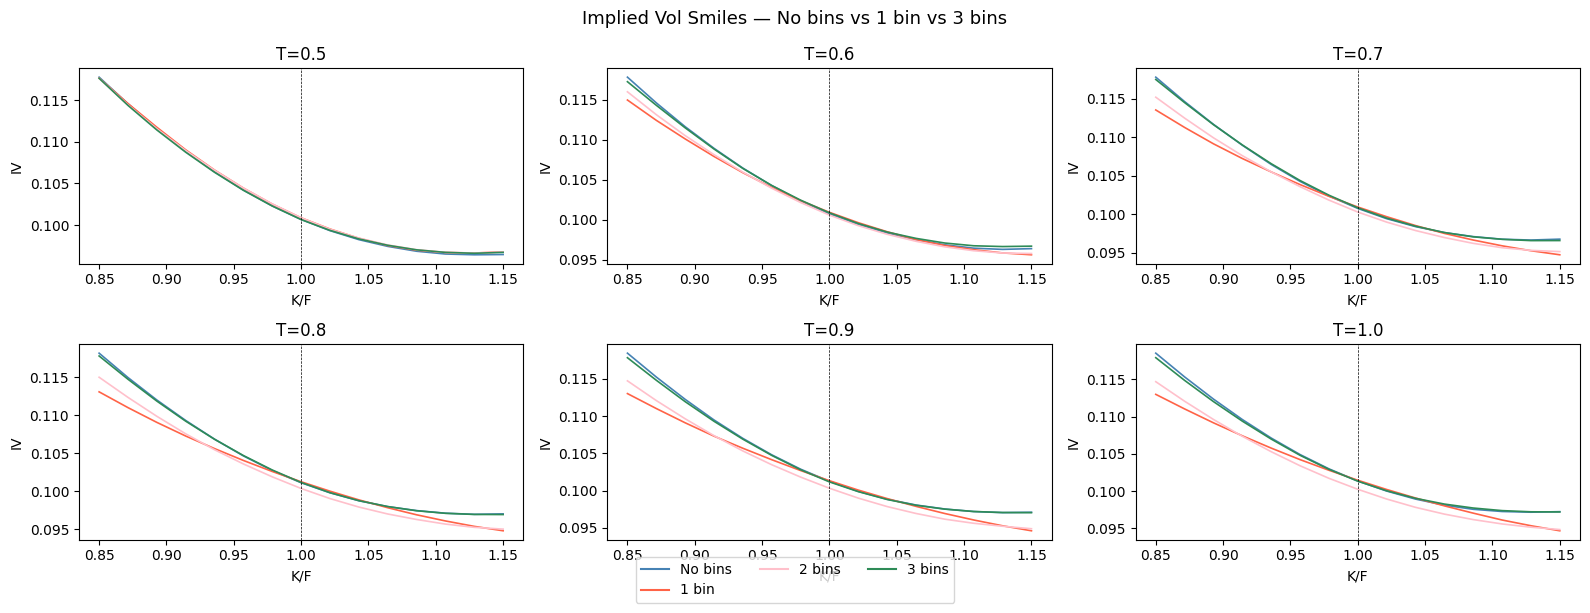

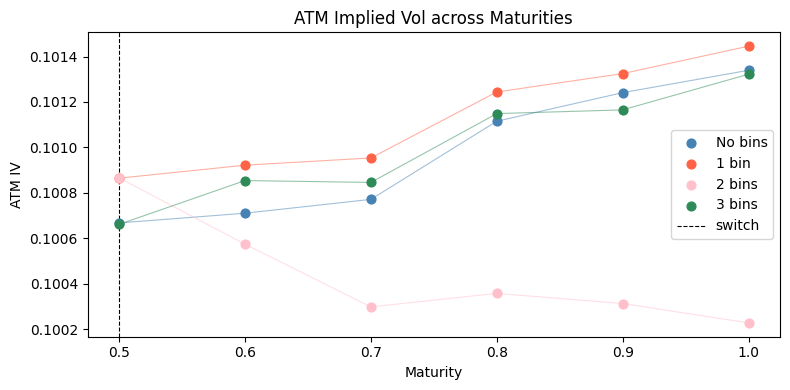

In [6]:
# Smile dependence
fig, axes = plt.subplots(2, 3, figsize=(16, 6))
fig.suptitle("Implied Vol Smiles — No bins vs 1 bin vs 3 bins", fontsize=13)

for ax, tau, slices in zip(axes.flat, maturities, zip(*[smiles[l] for l, _ in cases])):
    for (label, _), s in zip(cases, slices):
        mask = ~np.isnan(s["vols"])
        ax.plot(moneyness[mask], s["vols"][mask], lw=1.2, color=colors[label])
    ax.axvline(1, color="k", lw=0.5, ls="--")
    ax.set_title(f"T={tau:.1f}"); ax.set_xlabel("K/F"); ax.set_ylabel("IV")

handles = [plt.Line2D([0], [0], color=c, lw=1.5, label=l) for l, c in colors.items()]
fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(); plt.show()

# ATM vol
atm_idx = np.argmin(np.abs(moneyness - 1))
atm     = {label: [s["vols"][atm_idx] for s in sl] for label, sl in smiles.items()}

fig, ax = plt.subplots(figsize=(8, 4))
for label, vols in atm.items():
    ax.scatter(maturities, vols, s=40, color=colors[label], label=label, zorder=3)
    ax.plot(maturities, vols, lw=0.8, color=colors[label], alpha=0.5)
ax.axvline(switch_time, color="k", lw=0.8, ls="--", label="switch")
ax.set_title("ATM Implied Vol across Maturities")
ax.set_xlabel("Maturity"); ax.set_ylabel("ATM IV")
ax.legend(); plt.tight_layout(); plt.show()